# Model Testing — ml-25m (Optimized)

Validates all trained models with **vectorized batch prediction** (fast) instead of per-item loops.

Requires: `Train.ipynb` completed — files present in `models/`.

Sections:
1. Load all models
2. Metrics dashboard
3. Batch prediction functions (optimized)
4. Demo recommendations
5. Cold-start user test
6. IMDb Boost effect analysis
7. SVD GridSearch heatmap
8. Diversity & Novelty metrics


## 1. Load All Models

In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import random as _rnd
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity as cossim
from surprise import SVD
from tqdm.notebook import tqdm
from joblib import Parallel, delayed, parallel_backend


warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'text.color': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#e0e0e0', 'ytick.color': '#e0e0e0',
    'grid.color': '#ffffff20', 'grid.linestyle': '--',
})

MODELS_DIR = Path('models')

# ── Metadata ──────────────────────────────────────────────────────────────────
meta          = joblib.load(MODELS_DIR / 'model_metadata.pkl')
user_to_idx   = meta['user_to_idx']
movie_to_idx  = meta['movie_to_idx']
idx_to_movie  = meta['idx_to_movie']
best_alpha    = meta['best_alpha']
best_beta     = meta['best_beta']
imdb_norm_map = meta['imdb_norm_map']
r_min, r_max  = meta['rating_min'], meta['rating_max']
cold_start_thr= meta.get('cold_start_threshold', 5)
N_NEIGHBORS   = meta.get('n_neighbors', 50)
ACTIVITY_CAP  = meta.get('activity_cap', 200)
ALPHA_SWING   = meta.get('alpha_swing', 0.3)

# ── Model objects ─────────────────────────────────────────────────────────────
svd_best   = joblib.load(MODELS_DIR / 'svd_model.pkl')
itemcf_pkg = joblib.load(MODELS_DIR / 'itemcf_model.pkl')
content_pkg= joblib.load(MODELS_DIR / 'content_model.pkl')

knn_item             = itemcf_pkg['knn_item']
R                    = itemcf_pkg['R']
R_item               = itemcf_pkg['R_item']
user_content_profiles= content_pkg['user_profile']
movie_vec_sparse     = content_pkg['movie_vec']

# ── DataFrames ────────────────────────────────────────────────────────────────
df_train  = pd.read_csv(MODELS_DIR / 'df_train.csv')
df_test   = pd.read_csv(MODELS_DIR / 'df_test.csv')
df_movies = pd.read_csv(MODELS_DIR / 'movies_metadata_for_testing.csv')

# ── Precompute helpers ────────────────────────────────────────────────────────
user_activity_count = df_train.groupby('userId').size().to_dict()
popular_movies_ordered = (
    df_train.groupby('movieId').size()
    .sort_values(ascending=False)
    .index.tolist()
)
all_movie_ids = list(movie_to_idx.keys())
all_movie_set = set(all_movie_ids)

print("Precomputing item neighbors...")
_dist_pre, _idx_pre = knn_item.kneighbors(R_item, n_neighbors=N_NEIGHBORS + 1)
item_neighbor_idx = _idx_pre[:, 1:]          # (n_items, N_NEIGHBORS)
item_neighbor_sim = 1 - _dist_pre[:, 1:]     # (n_items, N_NEIGHBORS)
del _dist_pre, _idx_pre                       # giải phóng RAM
print(f"Done. item_neighbor_idx shape: {item_neighbor_idx.shape}")

print('All models loaded.')
print(f'  Users        : {len(user_to_idx):,}')
print(f'  Movies       : {len(movie_to_idx):,}')
print(f'  Best alpha   : {best_alpha}')
print(f'  Best beta    : {best_beta}')
print(f'  Cold-start   : < {cold_start_thr} ratings')


Precomputing item neighbors...
Done. item_neighbor_idx shape: (32199, 50)
All models loaded.
  Users        : 162,541
  Movies       : 32,199
  Best alpha   : 0.3
  Best beta    : 1.0
  Cold-start   : < 5 ratings


## 2. Metrics Dashboard

In [2]:
rmse = meta['rmse_scores']
mae  = meta['mae_scores']
prec = meta['precision_at_10']
rec  = meta['recall_at_10']

MODEL_KEYS = ['svd', 'itemcf', 'content', 'hybrid',
              'hybrid_boosted', 'hybrid_adaptive', 'hybrid_adaptive_boosted']

print(f'{"Model":<28} | {"RMSE":>7} | {"MAE":>7} | {"P@10":>7} | {"R@10":>7}')
print('-' * 75)
for m in MODEL_KEYS:
    print(f'{m:<28} | {rmse.get(m,0):>7.4f} | {mae.get(m,0):>7.4f} '
          f'| {prec.get(m,0):>7.4f} | {rec.get(m,0):>7.4f}')


Model                        |    RMSE |     MAE |    P@10 |    R@10
---------------------------------------------------------------------------
svd                          |  0.7778 |  0.5852 |  0.0032 |  0.0023
itemcf                       |  0.9439 |  0.6896 |  0.0154 |  0.0120
content                      |  1.8474 |  1.5179 |  0.0018 |  0.0014
hybrid                       |  0.8457 |  0.6280 |  0.0098 |  0.0054
hybrid_boosted               |  0.8899 |  0.6577 |  0.0154 |  0.0088
hybrid_adaptive              |  0.8837 |  0.6526 |  0.0082 |  0.0042
hybrid_adaptive_boosted      |  0.9269 |  0.6856 |  0.0136 |  0.0087


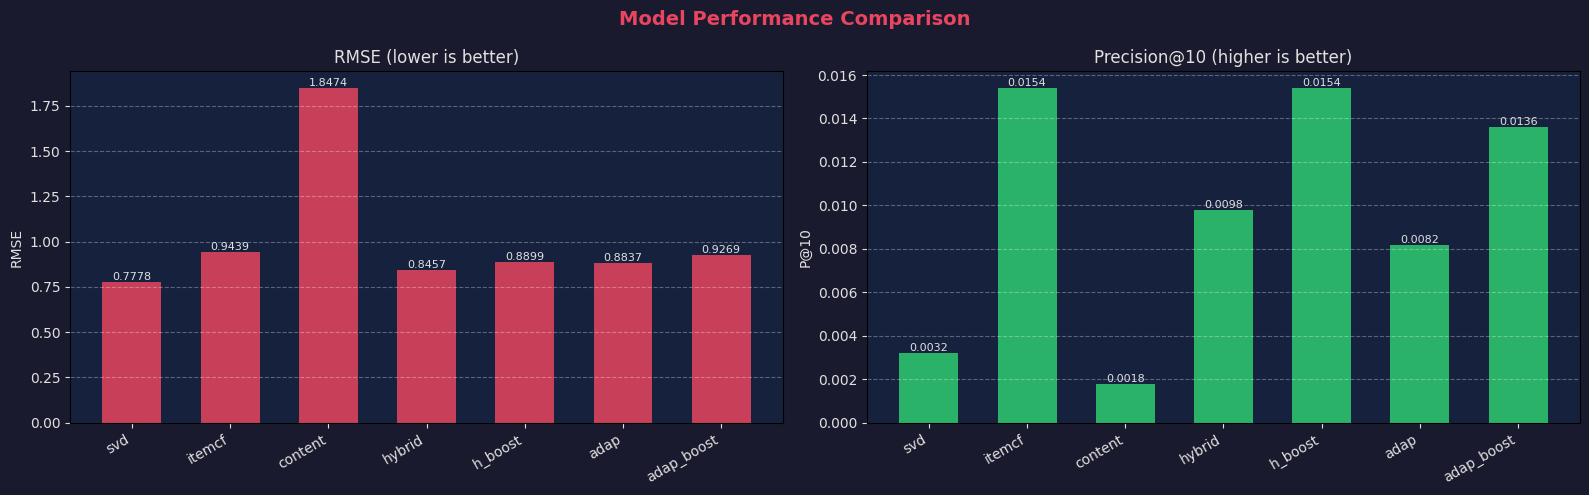

In [3]:
# ── Bar chart: RMSE + P@10 comparison ─────────────────────────────────────
labels   = [k.replace('hybrid_adaptive_boosted','adap_boost')
              .replace('hybrid_adaptive','adap')
              .replace('hybrid_boosted','h_boost')
              .replace('hybrid','hybrid') for k in MODEL_KEYS]
rmse_vals = [rmse.get(k, 0) for k in MODEL_KEYS]
prec_vals = [prec.get(k, 0) for k in MODEL_KEYS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', color='#e94560')

x = np.arange(len(labels))
bars = ax1.bar(x, rmse_vals, color='#e94560', alpha=0.85, width=0.6)
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=30, ha='right')
ax1.set_title('RMSE (lower is better)', color='#e0e0e0')
ax1.set_ylabel('RMSE')
ax1.bar_label(bars, fmt='%.4f', color='#e0e0e0', fontsize=8)
ax1.grid(axis='y', alpha=0.3)

bars2 = ax2.bar(x, prec_vals, color='#2ecc71', alpha=0.85, width=0.6)
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=30, ha='right')
ax2.set_title('Precision@10 (higher is better)', color='#e0e0e0')
ax2.set_ylabel('P@10')
ax2.bar_label(bars2, fmt='%.4f', color='#e0e0e0', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


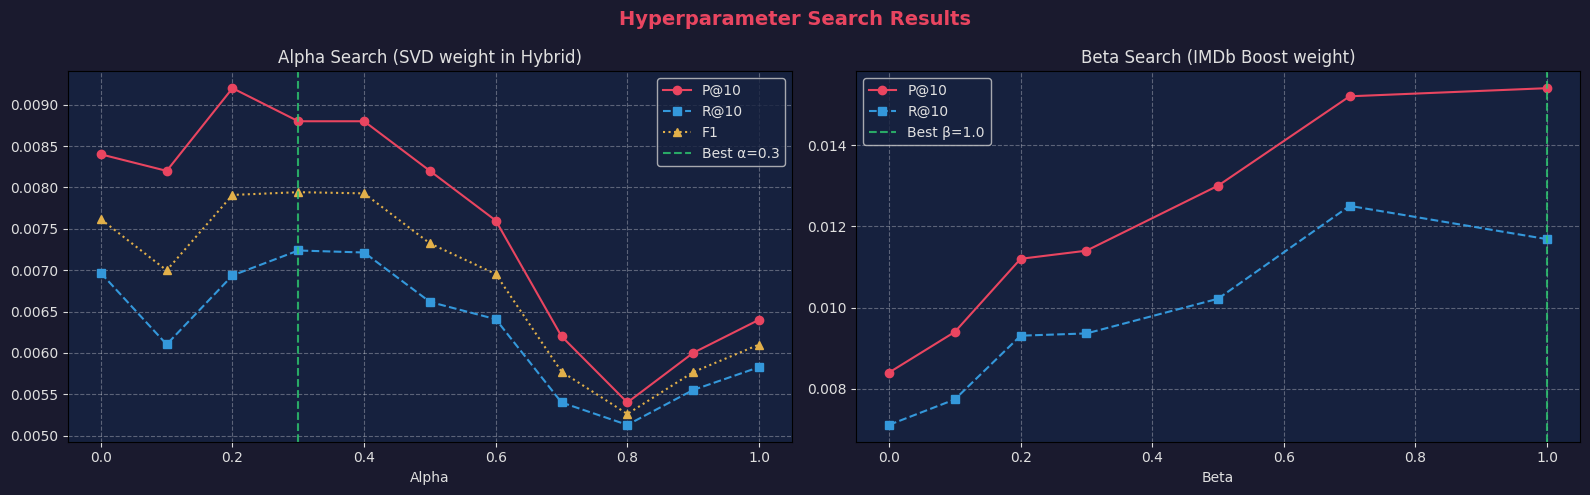

In [4]:
# ── Alpha / Beta search curves ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Hyperparameter Search Results', fontsize=14, fontweight='bold', color='#e94560')
fig.patch.set_facecolor('#1a1a2e')

if 'alpha_search_results' in meta:
    df_alpha = pd.DataFrame(meta['alpha_search_results'])
    axes[0].plot(df_alpha['alpha'], df_alpha['precision_10'], 'o-', color='#e94560', label='P@10')
    axes[0].plot(df_alpha['alpha'], df_alpha['recall_10'],    's--', color='#3498db', label='R@10')
    axes[0].plot(df_alpha['alpha'], df_alpha['f1'],           '^:',  color='#e2b04a', label='F1')
    axes[0].axvline(best_alpha, color='#2ecc71', linestyle='--', alpha=0.8, label=f'Best α={best_alpha}')
    axes[0].set_title('Alpha Search (SVD weight in Hybrid)', color='#e0e0e0')
    axes[0].set_xlabel('Alpha'); axes[0].legend(); axes[0].grid(alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'alpha_search_results not in metadata',
                 ha='center', va='center', transform=axes[0].transAxes, color='#888')

if 'beta_search_results' in meta:
    df_beta = pd.DataFrame(meta['beta_search_results'])
    axes[1].plot(df_beta['beta'], df_beta['precision_10'], 'o-', color='#e94560', label='P@10')
    axes[1].plot(df_beta['beta'], df_beta['recall_10'],    's--', color='#3498db', label='R@10')
    axes[1].axvline(best_beta, color='#2ecc71', linestyle='--', alpha=0.8, label=f'Best β={best_beta}')
    axes[1].set_title('Beta Search (IMDb Boost weight)', color='#e0e0e0')
    axes[1].set_xlabel('Beta'); axes[1].legend(); axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'beta_search_results not in metadata',
                 ha='center', va='center', transform=axes[1].transAxes, color='#888')

plt.tight_layout(); plt.show()


## 3. Batch Prediction Functions (Optimized)

Tất cả hàm predict đều dùng **vectorized / batch** thay vì loop từng phim:
- **SVD**: matrix ops (dot product) thay vì `surprise.predict()` 
- **ItemCF**: 1 lần `kneighbors` cho tất cả candidates cùng lúc  
- **Content**: stack ma trận, 1 lần `cosine_similarity`


In [5]:
# ── Helper ────────────────────────────────────────────────────────────────────
def adaptive_alpha_fn(uid):
    """Per-user alpha: cold users lean SVD, power users lean ItemCF."""
    n              = user_activity_count.get(uid, 0)
    activity_ratio = min(1.0, n / ACTIVITY_CAP)
    return float(np.clip(best_alpha + ALPHA_SWING * (1 - 2 * activity_ratio), 0.0, 1.0))


# ── OPT 1: Batch SVD — matrix ops, no per-item surprise.predict() ─────────────
def predict_svd_batch(uid, movie_ids):
    """
    Predict SVD scores for all movies at once via dot product.
    Returns list of floats (same order as movie_ids).
    """
    ts = svd_best.trainset
    try:
        inner_uid = ts.to_inner_uid(uid)
    except ValueError:
        return [float(ts.global_mean)] * len(movie_ids)

    pu  = svd_best.pu[inner_uid]
    bu  = svd_best.bu[inner_uid]
    gm  = ts.global_mean
    preds = []
    for mid in movie_ids:
        try:
            inner_iid = ts.to_inner_iid(mid)
            qi = svd_best.qi[inner_iid]
            bi = svd_best.bi[inner_iid]
            preds.append(float(np.clip(gm + bu + bi + np.dot(pu, qi), r_min, r_max)))
        except ValueError:
            preds.append(float(gm))
    return preds


# ── OPT 2: Batch ItemCF — 1 kneighbors call for all candidates ───────────────
def predict_itemcf_batch(uid, movie_ids, k=20):
    if uid not in user_to_idx:
        return [np.nan] * len(movie_ids)

    uidx     = user_to_idx[uid]
    user_row = R[uidx].toarray().flatten()   # (n_items,)

    valid_mids = [(pos, mid) for pos, mid in enumerate(movie_ids) if mid in movie_to_idx]
    preds      = [np.nan] * len(movie_ids)
    if not valid_mids:
        return preds

    positions = [p for p, _ in valid_mids]
    midxs     = np.array([movie_to_idx[m] for _, m in valid_mids])  # (n_valid,)

    # Lookup precomputed neighbors — không gọi kneighbors nữa
    neighbor_idxs = item_neighbor_idx[midxs]   # (n_valid, N_NEIGHBORS)
    neighbor_sims = item_neighbor_sim[midxs]   # (n_valid, N_NEIGHBORS)
    neighbor_rats = user_row[neighbor_idxs]    # (n_valid, N_NEIGHBORS)

    # Vectorized score cho tất cả candidates cùng lúc
    rated_mask   = neighbor_rats > 0                                      # (n_valid, N_NEIGHBORS)
    weighted_sum = (neighbor_sims * neighbor_rats * rated_mask).sum(axis=1)  # (n_valid,)
    sim_sum      = (neighbor_sims * rated_mask).sum(axis=1)                  # (n_valid,)

    scores = np.where(sim_sum > 0, weighted_sum / (sim_sum + 1e-9), np.nan)

    for i, pos in enumerate(positions):
        preds[pos] = float(scores[i])

    return preds

# ── OPT 3: Batch Content-Based — stacked cosine similarity ───────────────────
def predict_content_batch(uid, movie_ids):
    """
    Predict content scores for all movies via stacked matrix cosine sim.
    Returns list of floats (same order as movie_ids).
    """
    if uid not in user_content_profiles:
        return [np.nan] * len(movie_ids)

    u_profile  = user_content_profiles[uid].reshape(1, -1)
    valid_mids = [(pos, mid) for pos, mid in enumerate(movie_ids) if mid in movie_vec_sparse]
    preds      = [np.nan] * len(movie_ids)
    if not valid_mids:
        return preds

    movie_matrix = sp.vstack([movie_vec_sparse[m] for _, m in valid_mids])
    sims         = cossim(u_profile, movie_matrix)[0]
    for i, (pos, _) in enumerate(valid_mids):
        preds[pos] = float(r_min + sims[i] * (r_max - r_min))
    return preds


# ── Hybrid variants (built on top of batch functions) ─────────────────────────
def predict_hybrid_batch(uid, movie_ids, alpha=best_alpha):
    svd_p = predict_svd_batch(uid, movie_ids)
    icf_p = predict_itemcf_batch(uid, movie_ids)
    return [
        s if np.isnan(c) else (c if np.isnan(s) else float(alpha * s + (1 - alpha) * c))
        for s, c in zip(svd_p, icf_p)
    ]

def predict_hybrid_boosted_batch(uid, movie_ids, alpha=best_alpha, beta=best_beta):
    base = predict_hybrid_batch(uid, movie_ids, alpha=alpha)
    return [
        float(np.clip(b + beta * (imdb_norm_map.get(mid, 0.5) - 0.5), r_min, r_max))
        if not np.isnan(b) else np.nan
        for b, mid in zip(base, movie_ids)
    ]

def predict_hybrid_adaptive_batch(uid, movie_ids):
    alpha_u = adaptive_alpha_fn(uid)
    return predict_hybrid_batch(uid, movie_ids, alpha=alpha_u)

def predict_hybrid_adaptive_boosted_batch(uid, movie_ids, beta=best_beta):
    base = predict_hybrid_adaptive_batch(uid, movie_ids)
    return [
        float(np.clip(b + beta * (imdb_norm_map.get(mid, 0.5) - 0.5), r_min, r_max))
        if not np.isnan(b) else np.nan
        for b, mid in zip(base, movie_ids)
    ]


# ── Dict for easy iteration ───────────────────────────────────────────────────
ALL_MODELS = {
    'svd'                    : predict_svd_batch,
    'itemcf'                 : predict_itemcf_batch,
    'content'                : predict_content_batch,
    'hybrid'                 : predict_hybrid_batch,
    'hybrid_boosted'         : lambda u, m: predict_hybrid_boosted_batch(u, m, best_alpha, best_beta),
    'hybrid_adaptive'        : predict_hybrid_adaptive_batch,
    'hybrid_adaptive_boosted': predict_hybrid_adaptive_boosted_batch,
}

print('Batch prediction functions ready.')
print(f'  Alpha={best_alpha} | Beta={best_beta} | Cold-start thr={cold_start_thr}')


Batch prediction functions ready.
  Alpha=0.3 | Beta=1.0 | Cold-start thr=5


### Smart Candidate Selection

In [6]:
user_seen_movies = df_train.groupby('userId')['movieId'].apply(set).to_dict()

def get_candidates(uid, n_popular=1500, n_random=500):
    seen = user_seen_movies.get(uid, set())
    candidates = [m for m in all_movie_ids if m not in seen]
    if len(candidates) > n_popular + n_random:
        popular = [m for m in popular_movies_ordered if m not in seen][:n_popular]
        rest = list(set(candidates) - set(popular))
        rng = np.random.RandomState(uid % 100000)
        random_ = rng.choice(rest, min(n_random, len(rest)), replace=False).tolist()
        candidates = popular + random_
    return candidates



def recommend_batch(uid, predict_fn, k=10, min_imdb=0.0, exclude_seen=True, is_cold=False):
    """
    Recommend top-k movies using a batch predict function.
    Returns a styled DataFrame.
    """
    # Force Content-Based for cold-start users
    if is_cold:
        predict_fn = predict_content_batch

    candidates = get_candidates(uid, exclude_seen)
    scores     = predict_fn(uid, candidates)

    scored = [(m, s) for m, s in zip(candidates, scores) if not np.isnan(s)]
    scored.sort(key=lambda x: x[1], reverse=True)

    top_ids   = [m for m, _ in scored[:k * 3]]
    score_map = {m: s for m, s in scored}

    df_rec = df_movies[df_movies['movieId'].isin(top_ids)].copy()
    df_rec['pred_score'] = df_rec['movieId'].map(score_map)
    df_rec = df_rec.dropna(subset=['pred_score'])

    if min_imdb > 0 and 'imdb_score' in df_rec.columns:
        df_rec = df_rec[df_rec['imdb_score'] >= min_imdb]

    cols = ['title', 'genres', 'pred_score']
    if 'imdb_score' in df_rec.columns:
        cols.append('imdb_score')

    return df_rec.sort_values('pred_score', ascending=False).head(k)[cols].reset_index(drop=True)


## 4. Demo Recommendations

In [7]:
# Use most active user for demo
demo_user  = df_train['userId'].value_counts().index[0]
hist_count = user_activity_count.get(demo_user, 0)
is_cold    = hist_count < cold_start_thr

print(f'Demo user : {demo_user}  ({hist_count} ratings, cold={is_cold})')
print()

model_fns = {
    'SVD'                         : predict_svd_batch,
    'ItemCF'                      : predict_itemcf_batch,
    'Content-Based'               : predict_content_batch,
    'Hybrid'                      : predict_hybrid_batch,
    'Hybrid + IMDb Boost'         : lambda u, m: predict_hybrid_boosted_batch(u, m),
    'Adaptive Hybrid'             : predict_hybrid_adaptive_batch,
    'Adaptive Hybrid + IMDb Boost': predict_hybrid_adaptive_boosted_batch,
}

for name, fn in model_fns.items():
    print(f'--- {name} ---')
    df_r = recommend_batch(demo_user, fn, k=5, is_cold=is_cold)
    if df_r.empty:
        print('  No results.')
    else:
        print(df_r.to_string(index=False))
    print()


Demo user : 72315  (15643 ratings, cold=False)

--- SVD ---
                                                      title           genres  pred_score  imdb_score
                                     Here's the Plan (2016)  Animation|Drama    4.160694    0.606134
                                       Magnetic Rose (1995) Animation|Sci-Fi    4.069390    0.570676
                                      Saturday Night (2010)      Documentary    4.056096    0.602392
I Do Not Care If We Go Down in History as Barbarians (2018)            Drama    3.958742    0.592532
                   New Country, The (Det nya landet) (2000)     Comedy|Drama    3.871394    0.571688

--- ItemCF ---
                           title      genres  pred_score  imdb_score
The Chronicles of Melanie (2016)       Drama    4.252106    0.570676
    No Date, No Signature (2017)       Drama    4.220190    0.604772
      Run Silent Run Deep (1958)         War    3.905923    0.630227
               Submission (2017)       Dra

## 5. Cold-Start User Test

In [8]:
user_train_counts = df_train['userId'].value_counts()
cold_candidates_  = user_train_counts[user_train_counts < cold_start_thr]
cold_user   = cold_candidates_.index[0] if not cold_candidates_.empty else user_train_counts.index[-1]
cold_count  = user_train_counts[cold_user]

print(f'Cold-start user : {cold_user}  ({cold_count} ratings)')
print(f'Threshold       : < {cold_start_thr} → using Content-Based automatically')
print()

cold_history = df_train[df_train['userId'] == cold_user].merge(
    df_movies[['movieId', 'title']], on='movieId'
)
print('Watched movies:')
print(cold_history[['title', 'rating']].to_string(index=False))
print()

print('Recommendations (Content-Based forced):')
df_cold_rec = recommend_batch(cold_user, predict_content_batch, k=10, is_cold=True)
print(df_cold_rec.to_string(index=False))


Cold-start user : 10861  (7 ratings)
Threshold       : < 5 → using Content-Based automatically

Watched movies:
                                     title  rating
                          Kickboxer (1989)     5.0
                         Bloodsport (1988)     5.0
                      Mortal Kombat (1995)     5.0
Ong-Bak: The Thai Warrior (Ong Bak) (2003)     5.0
                 The Wrath Of Vajra (2013)     5.0
      Hercules Against the Moon Men (1964)     5.0
        Tarzan's Greatest Adventure (1959)     5.0

Recommendations (Content-Based forced):
                        title             genres  pred_score  imdb_score
         Code of Honor (2016)             Action    4.999999    0.423871
       American Strays (1996)             Action    4.999999    0.557790
     Acts of Vengeance (2017)             Action    4.999999    0.518899
Kickboxer: Retaliation (2018)       Action|Drama    4.999999    0.462564
            11 Minutes (2015) (no genres listed)    4.999999    0.525305
G

## 6. IMDb Boost Effect Analysis

In [9]:
boost_user = df_train['userId'].value_counts().index[5]
print(f'User: {boost_user}  ({user_activity_count.get(boost_user,0)} ratings)')

rec_hybrid  = recommend_batch(boost_user, predict_hybrid_batch,         k=10)
rec_boosted = recommend_batch(boost_user, lambda u,m: predict_hybrid_boosted_batch(u,m), k=10)

print('\n--- Hybrid (no boost) ---')
print(rec_hybrid.to_string(index=False))
print('\n--- Hybrid + IMDb Boost ---')
print(rec_boosted.to_string(index=False))

if 'imdb_score' in rec_hybrid.columns:
    avg_no = rec_hybrid['imdb_score'].mean()
    avg_b  = rec_boosted['imdb_score'].mean()
    print(f'\nAvg IMDb — no boost : {avg_no:.3f}')
    print(f'Avg IMDb — boosted  : {avg_b:.3f}')
    print(f'Improvement         : {avg_b - avg_no:+.3f}')


User: 109731  (4568 ratings)

--- Hybrid (no boost) ---
                                                  title                        genres  pred_score  imdb_score
                                   Vietnam in HD (2011)                           War    3.717814    0.586980
                The Night Is Short, Walk on Girl (2017)             Animation|Romance    3.701071    0.694234
                       Fires on the Plain (Nobi) (1959)                     Drama|War    3.683288    0.668398
                                     War Stories (1995)                   Documentary    3.631317    0.570676
                                    Interstellar (2014)                   Sci-Fi|IMAX    3.578591    0.956627
                                 Zabriskie Point (1970)                 Drama|Romance    3.564018    0.660424
                                         Pageant (2008)                   Documentary    3.544022    0.545235
Gas, Inspector Palmu! (Kaasua, komisario Palmu!) (1961) Comedy|C

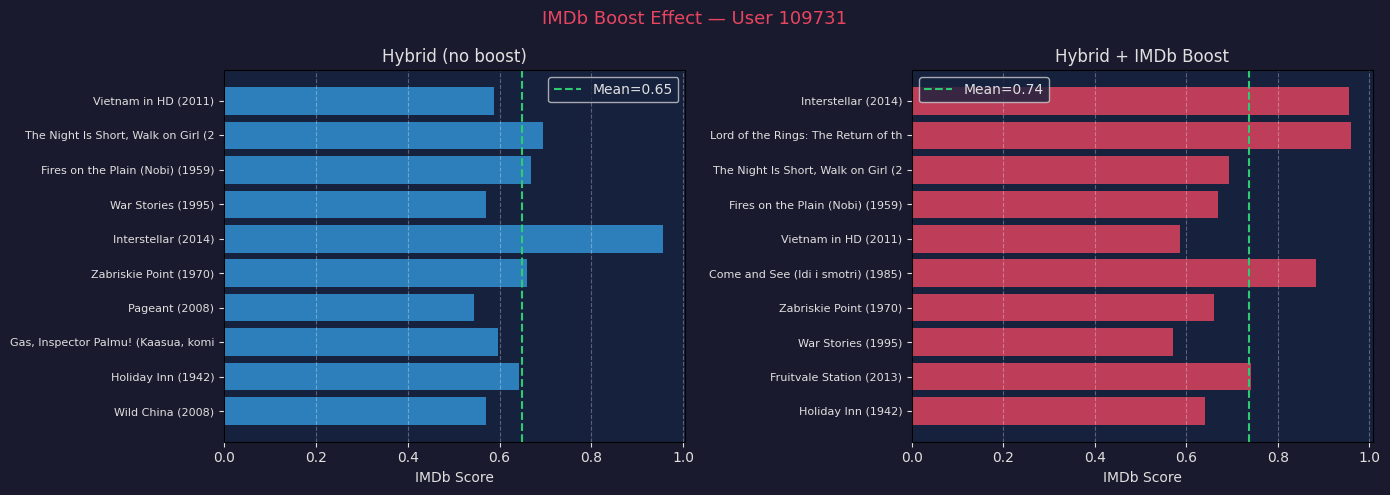

In [10]:
# ── Visualize IMDb score distribution: boosted vs not ───────────────────────
if 'imdb_score' in rec_hybrid.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'IMDb Boost Effect — User {boost_user}', fontsize=13, color='#e94560')

    for ax, df_r, title, color in [
        (axes[0], rec_hybrid,  'Hybrid (no boost)', '#3498db'),
        (axes[1], rec_boosted, 'Hybrid + IMDb Boost', '#e94560'),
    ]:
        ax.barh(range(len(df_r)), df_r['imdb_score'].fillna(0), color=color, alpha=0.8)
        ax.set_yticks(range(len(df_r)))
        labels_ = [t[:35] for t in df_r['title'].tolist()]
        ax.set_yticklabels(labels_, fontsize=8)
        ax.set_xlabel('IMDb Score')
        ax.set_title(title, color='#e0e0e0')
        ax.axvline(df_r['imdb_score'].mean(), color='#2ecc71', linestyle='--',
                   label=f'Mean={df_r["imdb_score"].mean():.2f}')
        ax.legend(); ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()

    plt.tight_layout(); plt.show()


## 7. SVD GridSearch Heatmap

Top 15 SVD configurations:


,n_factors,n_epochs,lr_all,reg_all,random_state,rmse_valid,mae_valid
0,150,50,0.010,0.05,42,0.776574,0.585354
1,200,50,0.010,0.05,42,0.776950,0.585581
2,100,50,0.010,0.05,42,0.776975,0.585517
3,50,50,0.010,0.05,42,0.778329,0.586588
4,150,30,0.010,0.05,42,0.779616,0.587813
5,200,30,0.010,0.05,42,0.779618,0.587900
6,100,30,0.010,0.05,42,0.779629,0.587733
7,200,50,0.005,0.05,42,0.780529,0.588607
8,100,50,0.005,0.05,42,0.780593,0.588522
9,150,50,0.005,0.05,42,0.780655,0.588554


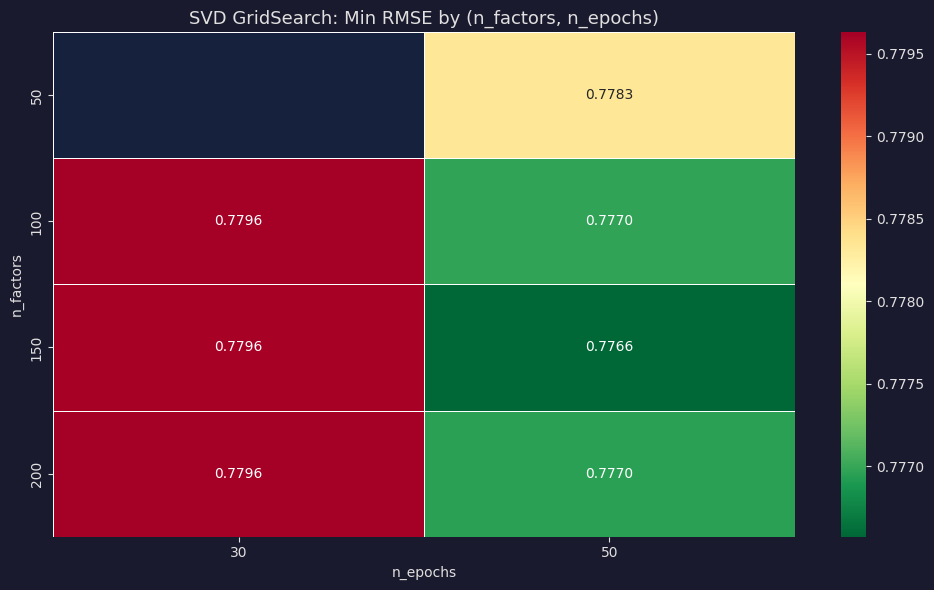

Best SVD params: {'n_factors': 150, 'n_epochs': 50, 'lr_all': 0.01, 'reg_all': 0.05, 'random_state': 42}


In [11]:
if 'grid_search_results' in meta:
    df_grid = pd.DataFrame(meta['grid_search_results']).sort_values('rmse_valid')
    print('Top 15 SVD configurations:')
    display(df_grid.head(15))

    pivot = df_grid.groupby(['n_factors', 'n_epochs'])['rmse_valid'].min().unstack()
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#1a1a2e')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=ax,
                linewidths=0.5, annot_kws={'size': 10})
    ax.set_title('SVD GridSearch: Min RMSE by (n_factors, n_epochs)', color='#e0e0e0', fontsize=13)
    ax.set_xlabel('n_epochs'); ax.set_ylabel('n_factors')
    plt.tight_layout()
    plt.savefig('data/cleaning/viz_gridsearch_heatmap.png', dpi=120,
                bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()
    print(f'Best SVD params: {meta["best_svd_params"]}')
else:
    print('grid_search_results not found in metadata.')


## 8. Diversity & Novelty Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Diversity (ILD)** | avg pairwise Jaccard genre distance in top-K | 0=same genre, 1=maximally diverse |
| **Novelty** | avg $-\log_2(\text{popularity})$ of top-K | higher = less mainstream |
| **Coverage** | fraction of catalog in any recommendation | low = always same popular films |


In [12]:
# ── Genre & popularity helpers ────────────────────────────────────────────────
genre_sets = {}
for _, row in df_movies.iterrows():
    g = row.get('genres', '')
    if isinstance(g, list):
        genre_sets[row['movieId']] = set(g)
    elif isinstance(g, str):
        genre_sets[row['movieId']] = set(g.split('|')) if g else set()

total_train_users = df_train['userId'].nunique()
movie_pop = (df_train.groupby('movieId')['userId'].nunique() / total_train_users).to_dict()

def jaccard_distance(a, b):
    sa = genre_sets.get(a, set()); sb = genre_sets.get(b, set())
    if not sa and not sb: return 0.0
    return 1 - len(sa & sb) / len(sa | sb)

all_genres = sorted({g for gs in genre_sets.values() for g in gs})
genre_to_idx_map = {g: i for i, g in enumerate(all_genres)}
G = len(all_genres)

movie_genre_matrix = {}
for mid, gs in genre_sets.items():
    vec = np.zeros(G, dtype=np.float32)
    for g in gs:
        vec[genre_to_idx_map[g]] = 1.0
    movie_genre_matrix[mid] = vec

def intra_list_diversity(movie_list):
    if len(movie_list) < 2:
        return 0.0
    vecs = np.stack([movie_genre_matrix.get(m, np.zeros(G, dtype=np.float32)) for m in movie_list])
    # Jaccard = intersection / union cho mỗi cặp
    inter = vecs @ vecs.T                  # (k, k)
    norms = vecs.sum(axis=1, keepdims=True)
    union = norms + norms.T - inter        # (k, k)
    with np.errstate(divide='ignore', invalid='ignore'):
        jac_sim = np.where(union > 0, inter / union, 0.0)
    dist = 1 - jac_sim
    k = len(movie_list)
    return float(dist[np.triu_indices(k, k=1)].mean())

def novelty(movie_list):
    if not movie_list: return 0.0
    return float(np.mean([-np.log2(movie_pop.get(m, 1e-6) + 1e-10) for m in movie_list]))

print(f'Genre sets   : {len(genre_sets):,} movies')
print(f'Popularity   : {len(movie_pop):,} movies')


Genre sets   : 32,720 movies
Popularity   : 32,199 movies


In [13]:
# ── Diversity / Novelty evaluation ───────────────────────────────────────────
gt_test = df_test.groupby('userId')['movieId'].apply(set).to_dict()

_rnd.seed(77)
eval_users_div = _rnd.sample(
    [u for u in gt_test.keys() if u in user_to_idx],
    min(200, len(gt_test))
)
print(f'Evaluating on {len(eval_users_div)} users (k=10)...')

def _eval_one_user(uid, predict_fn, k=10):
    candidates = get_candidates(uid)
    with parallel_backend('threading', n_jobs=1):
        scores = predict_fn(uid, candidates)
    
    scored = sorted(
        [(m, s) for m, s in zip(candidates, scores) if not np.isnan(s)],
        key=lambda x: x[1], reverse=True
    )
    top_k = [m for m, _ in scored[:k]]
    if not top_k:
        return None, None, set()
    return intra_list_diversity(top_k), novelty(top_k), set(top_k)


def eval_diversity_novelty(predict_fn, users, k=10, n_jobs=4):
    results = Parallel(n_jobs=n_jobs, prefer='threads')(
        delayed(_eval_one_user)(uid, predict_fn, k) for uid in users
    )
    ilds = [r[0] for r in results if r[0] is not None]
    novs = [r[1] for r in results if r[1] is not None]
    covered = set().union(*[r[2] for r in results])
    coverage = len(covered) / len(all_movie_ids)
    return (float(np.mean(ilds)) if ilds else 0.0,
            float(np.mean(novs)) if novs else 0.0,
            coverage)

div_results = {}
for name, fn in ALL_MODELS.items():
    print(f'  {name}...')
    ild, nov, cov = eval_diversity_novelty(fn, eval_users_div)
    div_results[name] = {'diversity_ild': ild, 'novelty': nov, 'coverage': cov}

print()
print('=' * 70)
print(f'{"Model":<25} {"Diversity(ILD)":>14} {"Novelty":>9} {"Coverage":>10}')
print('=' * 70)
for model, m in div_results.items():
    print(f'{model:<25} {m["diversity_ild"]:>14.4f} {m["novelty"]:>9.4f} {m["coverage"]:>10.4f}')
print('=' * 70)


Evaluating on 200 users (k=10)...
  svd...
  itemcf...
  content...
  hybrid...
  hybrid_boosted...
  hybrid_adaptive...
  hybrid_adaptive_boosted...

Model                     Diversity(ILD)   Novelty   Coverage
svd                               0.7789    5.7047     0.0210
itemcf                            0.7679    4.2037     0.0295
content                           0.3188    6.7456     0.0142
hybrid                            0.7446    5.0930     0.0279
hybrid_boosted                    0.7483    3.4735     0.0172
hybrid_adaptive                   0.7487    5.3232     0.0279
hybrid_adaptive_boosted           0.7431    3.5124     0.0167


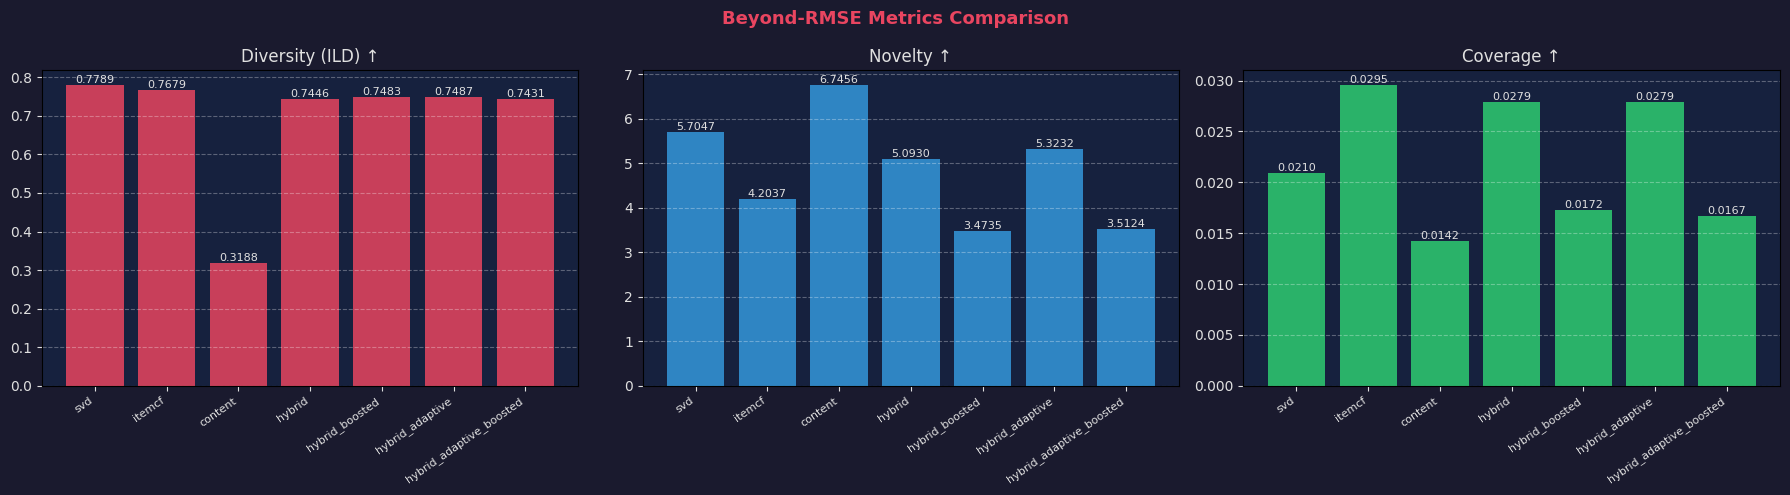

In [14]:
# ── Radar / bar chart for diversity metrics ───────────────────────────────────
df_div = pd.DataFrame(div_results).T.reset_index().rename(columns={'index': 'model'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Beyond-RMSE Metrics Comparison', fontsize=13, fontweight='bold', color='#e94560')

for ax, col, color, label in [
    (axes[0], 'diversity_ild', '#e94560', 'Diversity (ILD) ↑'),
    (axes[1], 'novelty',       '#3498db', 'Novelty ↑'),
    (axes[2], 'coverage',      '#2ecc71', 'Coverage ↑'),
]:
    bars = ax.bar(df_div['model'], df_div[col], color=color, alpha=0.85)
    ax.set_title(label, color='#e0e0e0')
    ax.set_xticklabels(df_div['model'], rotation=35, ha='right', fontsize=8)
    ax.bar_label(bars, fmt='%.4f', color='#e0e0e0', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()
